In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 31.4 MB


In [7]:
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,...,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000
mean,0.890360,0.758160,0.423972,0.219104,0.201127,0.210399,0.205808,0.201773,0.198691,0.196757,...,0.005025,0.004628,0.004291,0.003945,0.003681,0.003471,0.003221,0.002945,0.002807,0.473376
std,0.240909,0.221813,0.227305,0.206878,0.177058,0.171909,0.178481,0.177240,0.171778,0.168357,...,0.044154,0.042089,0.040525,0.038651,0.037193,0.036255,0.034789,0.032865,0.031924,1.143184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.921922,0.682486,0.250969,0.048458,0.082329,0.088416,0.073333,0.066116,0.065000,0.068639,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991342,0.826013,0.429472,0.166000,0.147878,0.158798,0.145324,0.144424,0.150000,0.148734,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.910506,0.578767,0.341727,0.258993,0.287628,0.298237,0.295391,0.290832,0.283636,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [8]:
test_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,...,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000
mean,0.894410,0.761902,0.426627,0.221596,0.201676,0.209891,0.204805,0.200992,0.197634,0.196022,...,0.004588,0.004327,0.004020,0.003789,0.003638,0.003459,0.003166,0.003000,0.002946,0.473689
std,0.234560,0.218659,0.228572,0.208711,0.177727,0.172194,0.177946,0.176142,0.170228,0.166707,...,0.043128,0.042187,0.040255,0.039397,0.038535,0.037717,0.035903,0.035522,0.035266,1.143447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.924260,0.683366,0.251197,0.050505,0.082873,0.087912,0.072663,0.065997,0.064516,0.068493,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.990431,0.828996,0.432777,0.167630,0.147642,0.158111,0.144068,0.144509,0.150422,0.149029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.912319,0.583991,0.347092,0.259211,0.287356,0.298453,0.294563,0.289907,0.282956,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.991429,...,0.980392,1.000000,0.966102,1.000000,1.000000,1.000000,1.000000,0.996053,1.000000,4.000000


In [9]:
train_df.shape

(87554, 188)

In [10]:
test_df.shape

(21892, 188)

In [11]:
train_df[187].value_counts()

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

In [12]:
X_train = train_df.iloc[:,:-1].values
y_train = train_df.iloc[:,-1].values.astype(int)

X_test = test_df.iloc[:,:-1].values
y_test = test_df.iloc[:,-1].values.astype(int)

In [13]:
X_train = torch.tensor(X_train, dtype = torch.float32).view(-1, 1, 187) #187 = 188(no. of cols) - 1(label)
y_train = torch.tensor(y_train, dtype = torch.long)

In [14]:
X_test = torch.tensor(X_test, dtype = torch.float32).view(-1,1,187)
y_test = torch.tensor(y_test, dtype = torch.long)

In [15]:
print(X_train.shape, X_train.dtype)   # torch.Size([87554, 1, 187]) torch.float32
print(y_train.shape, y_train.dtype)   # torch.Size([87554]) torch.int64
print(y_train.unique())               # tensor([0, 1, 2, 3, 4])

torch.Size([87554, 1, 187]) torch.float32
torch.Size([87554]) torch.int64
tensor([0, 1, 2, 3, 4])


In [16]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 128
train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_l = DataLoader(test_ds, batch_size=batch_size, shuffle = False)

Text(0.5, 1.0, 'label 0')

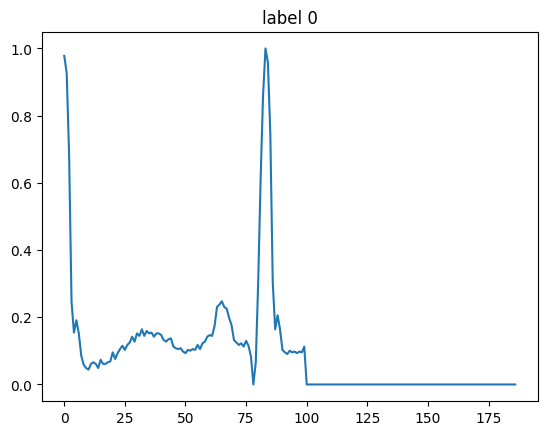

In [17]:
plt.plot(X_train[0].squeeze())
plt.title(f'label {y_train[0].item()}')

In [18]:
n_classes = len(y_train.unique())
L = X_train.shape[2]   

In [19]:
#helper function

def cbr(in_ch, out_ch, k=3, stride=1):
    return nn.Sequential(
        nn.Conv1d(in_ch, out_ch, k, stride = stride, padding=(k-1)//2, bias = False),
        nn.BatchNorm1d(out_ch),
        nn.ReLU(inplace=True)
    )

In [20]:
def receptive_field(layers):
    rf, jump = 1, 1
    for k, s in layers:
        rf += (k - 1) * jump
        jump *= s
    return rf

layers, n = [], 0
while receptive_field(layers) < L:
    layers += [(3,1), (2,2)]
    n += 1
    print(n, receptive_field(layers), L // 2**n)

1 4 93
2 10 46
3 22 23
4 46 11
5 94 5
6 190 2


In [21]:
n_layers = 5

In [22]:
def trace(model, L=187):
    hooks = []
    def hook(m, i, o):
        print(f'{m.__class__.__name__:<20} {tuple(o.shape)}')
    for m in model.modules():
        if not list(m.children()):
            hooks.append(m.register_forward_hook(hook))
    model(torch.randn(2, 1, L))
    for h in hooks:
        h.remove()

VGG:

In [23]:
class ECG_CNN1D_VGG(nn.Module):
    def __init__(self, n_classes = n_classes):
        super().__init__()
        self.cbr1 = cbr(1, 32, k=7)
        self.cbr2 = cbr(32, 64, k=7)
        self.cbr3 = cbr(64, 128, k=5)
        self.cbr4 = cbr(128, 128, k=3)
        self.cbr5 = cbr(128,128,k=3)
        self.p = nn.MaxPool1d(2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.op = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.cbr1(x)
        x = self.p(x)
        x = self.cbr2(x)
        x = self.p(x)
        x = self.cbr3(x)
        x = self.p(x)
        x = self.cbr4(x)
        x = self.p(x)
        x = self.cbr5(x)
        x = self.p(x)
        x = self.gap(x).flatten(1)
        x = self.op(x)
        return x

model = ECG_CNN1D_VGG().to(device)
print(model)

ECG_CNN1D_VGG(
  (cbr1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (cbr2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (cbr3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (cbr4): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (cbr5): Sequential(
    (0): Conv1d(128

RESNET:

In [24]:
class Resb(nn.Module):
    def __init__(self, ch, k=3):
        super().__init__()
        self.c1 = nn.Conv1d(ch, ch, k, padding=(k-1)//2, bias=False)
        self.b1 = nn.BatchNorm1d(ch)
        self.c2 = nn.Conv1d(ch, ch, k, padding=(k-1)//2, bias=False)
        self.b2 = nn.BatchNorm1d(ch)

    def forward(self, x):
        ip = x
        y = self.b1(self.c1(x))
        y = F.relu(y)
        y = self.b2(self.c2(y))
        return F.relu(y+ip)

In [25]:
class ECG_CNN1D_RESNET(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.stem = cbr(1,32, k=7)
        self.r1 = Resb(32)
        self.up1 = cbr(32, 64, k=1)
        self.r2 = Resb(64)
        self.up2 = cbr(64, 80, k=1)
        self.r3 = Resb(80)
        self.r4 = Resb(80)
        self.r5 = Resb(80)
        self.p = nn.MaxPool1d(2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.op = nn.Linear(80, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.up1(self.p(self.r1(x)))
        x = self.up2(self.p(self.r2(x)))
        x = self.p(self.r3(x))
        x = self.p(self.r4(x))
        x = self.p(self.r5(x))
        x = self.gap(x).flatten(1)
        x = self.op(x)
        return x

model = ECG_CNN1D_RESNET().to(device)
print(model)

ECG_CNN1D_RESNET(
  (stem): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (r1): Resb(
    (c1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (c2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (up1): Sequential(
    (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (r2): Resb(
    (c1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b1): BatchNorm1d(64, eps=1e-05, momentum=0.

DILATED RESNET:

In [26]:
class DilResb(nn.Module):
    def __init__(self, ch, k=3, dilation=1):
        super().__init__()
        pad = dilation * (k-1)//2
        self.c1 = nn.Conv1d(ch, ch, k, padding = pad, dilation=dilation, bias = False)
        self.b1 = nn.BatchNorm1d(ch)
        self.c2 = nn.Conv1d(ch, ch, k, padding = pad, dilation=dilation, bias = False)
        self.b2 = nn.BatchNorm1d(ch)

    def forward(self, x):
        ip = x
        y = self.b1(self.c1(x))
        y = F.relu(y)
        y = self.b2(self.c2(y))
        return F.relu(y+ip)

In [27]:
class ECG_CNN1D_DILRESNET(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.stem = cbr(1, 64, k=7)
        self.d1 = DilResb(64, dilation=1)
        self.d2 = DilResb(64, dilation=2)
        self.d3 = DilResb(64, dilation=4)
        self.d4 = DilResb(64, dilation=8)
        self.d5 = DilResb(64, dilation=16)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.op = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)
        x = self.d5(x)
        x = self.gap(x).flatten(1)
        x = self.op(x)
        return x

model = ECG_CNN1D_DILRESNET().to(device)
print(model)


ECG_CNN1D_DILRESNET(
  (stem): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (d1): DilResb(
    (c1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (c2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (d2): DilResb(
    (c1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
    (b1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (c2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
    (b2): BatchNorm1d(64, eps=1e-05, momentum=

In [28]:
for M in [ECG_CNN1D_VGG]:
    m = M(n_classes)
    params = sum(p.numel() for p in m.parameters())
    out = m(torch.randn(2, 1, 187)).shape
    print(f'{M.__name__:15} params:{params:>6}  out={tuple(out)}')

ECG_CNN1D_VGG   params:155429  out=(2, 5)


In [29]:
trace(ECG_CNN1D_VGG(n_classes))

Conv1d               (2, 32, 187)
BatchNorm1d          (2, 32, 187)
ReLU                 (2, 32, 187)
MaxPool1d            (2, 32, 93)
Conv1d               (2, 64, 93)
BatchNorm1d          (2, 64, 93)
ReLU                 (2, 64, 93)
MaxPool1d            (2, 64, 46)
Conv1d               (2, 128, 46)
BatchNorm1d          (2, 128, 46)
ReLU                 (2, 128, 46)
MaxPool1d            (2, 128, 23)
Conv1d               (2, 128, 23)
BatchNorm1d          (2, 128, 23)
ReLU                 (2, 128, 23)
MaxPool1d            (2, 128, 11)
Conv1d               (2, 128, 11)
BatchNorm1d          (2, 128, 11)
ReLU                 (2, 128, 11)
MaxPool1d            (2, 128, 5)
AdaptiveAvgPool1d    (2, 128, 1)
Linear               (2, 5)


In [30]:
def train_model(model, epochs=15, lr=1e-3, criterion=None):
    torch.manual_seed(42)
    model = model.to(device)
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-2)

    tr_losses, te_losses = [], []
    t0 = time.time()

    for epoch in range(epochs):

        # training
        model.train()
        tr_b_loss = []
        for X_batch, y_batch in train_l:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr_b_loss.append(loss.item())
        tr_losses.append(np.mean(tr_b_loss))

        # testing
        model.eval()
        te_b_loss = []
        with torch.no_grad():
            for X_batch, y_batch in test_l:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                te_b_loss.append(loss.item())
        te_losses.append(np.mean(te_b_loss))

        if (epoch+1) % 2 == 0:
            print(f' Epoch: {epoch+1:2d}/{epochs} | Train loss: {tr_losses[-1]:.4f} | Test loss: {te_losses[-1]:.4f}')

    return model, tr_losses, te_losses, (time.time()-t0)/epochs

In [31]:
def evaluate(model, name=''):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in test_l:
            preds.append(model(X_batch.to(device)).argmax(1).cpu())
    pred = torch.cat(preds)
    print(name)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3))
    return pred

In [32]:
'''results = {}
for M in [ECG_CNN1D_VGG]:
    results[M.__name__] = train_model(M(n_classes))

evaluate(results['ECG_CNN1D_VGG'][0], 'VGG')'''

"results = {}\nfor M in [ECG_CNN1D_VGG]:\n    results[M.__name__] = train_model(M(n_classes))\n\nevaluate(results['ECG_CNN1D_VGG'][0], 'VGG')"

Accuracy: 0.985

Macro F1: 0.918

class 0: 0.993

class 1: 0.855

class 2: 0.955

class 3: 0.799

class 4: 0.988

Therefore, class 1 and 3 are reducing the macro f1 down from 0.985 to 0.918

Testing All 3 Now:

In [33]:
for M in [ECG_CNN1D_VGG, ECG_CNN1D_RESNET, ECG_CNN1D_DILRESNET]:
    m = M(n_classes)
    params = sum(p.numel() for p in m.parameters())
    out = m(torch.randn(2, 1, 187)).shape
    print(f'{M.__name__:15} params:{params:>6}  out={tuple(out)}')

ECG_CNN1D_VGG   params:155429  out=(2, 5)
ECG_CNN1D_RESNET params:155413  out=(2, 5)


ECG_CNN1D_DILRESNET params:125061  out=(2, 5)


In [34]:
for M in [ECG_CNN1D_VGG, ECG_CNN1D_RESNET, ECG_CNN1D_DILRESNET]:
    print(f'===== {M.__name__} =====')
    trace(M(n_classes))
    print()

===== ECG_CNN1D_VGG =====
Conv1d               (2, 32, 187)
BatchNorm1d          (2, 32, 187)
ReLU                 (2, 32, 187)
MaxPool1d            (2, 32, 93)
Conv1d               (2, 64, 93)
BatchNorm1d          (2, 64, 93)
ReLU                 (2, 64, 93)
MaxPool1d            (2, 64, 46)
Conv1d               (2, 128, 46)
BatchNorm1d          (2, 128, 46)
ReLU                 (2, 128, 46)
MaxPool1d            (2, 128, 23)
Conv1d               (2, 128, 23)
BatchNorm1d          (2, 128, 23)
ReLU                 (2, 128, 23)
MaxPool1d            (2, 128, 11)
Conv1d               (2, 128, 11)
BatchNorm1d          (2, 128, 11)
ReLU                 (2, 128, 11)
MaxPool1d            (2, 128, 5)
AdaptiveAvgPool1d    (2, 128, 1)
Linear               (2, 5)

===== ECG_CNN1D_RESNET =====
Conv1d               (2, 32, 187)
BatchNorm1d          (2, 32, 187)
ReLU                 (2, 32, 187)
Conv1d               (2, 32, 187)
BatchNorm1d          (2, 32, 187)
Conv1d               (2, 32, 187)
Batch

In [35]:
results = {}
for M in [ECG_CNN1D_VGG, ECG_CNN1D_RESNET, ECG_CNN1D_DILRESNET]:
    print(f'===== {M.__name__} =====')
    results[M.__name__] = train_model(M(n_classes))
    print()

===== ECG_CNN1D_VGG =====
 Epoch:  2/15 | Train loss: 0.0719 | Test loss: 0.1178
 Epoch:  4/15 | Train loss: 0.0493 | Test loss: 0.0612
 Epoch:  6/15 | Train loss: 0.0398 | Test loss: 0.0735
 Epoch:  8/15 | Train loss: 0.0325 | Test loss: 0.0592
 Epoch: 10/15 | Train loss: 0.0278 | Test loss: 0.0541
 Epoch: 12/15 | Train loss: 0.0232 | Test loss: 0.0529
 Epoch: 14/15 | Train loss: 0.0182 | Test loss: 0.0534

===== ECG_CNN1D_RESNET =====
 Epoch:  2/15 | Train loss: 0.0733 | Test loss: 0.7772
 Epoch:  4/15 | Train loss: 0.0531 | Test loss: 0.0619
 Epoch:  6/15 | Train loss: 0.0421 | Test loss: 0.1011
 Epoch:  8/15 | Train loss: 0.0373 | Test loss: 0.0934
 Epoch: 10/15 | Train loss: 0.0299 | Test loss: 0.0550
 Epoch: 12/15 | Train loss: 0.0261 | Test loss: 0.0525
 Epoch: 14/15 | Train loss: 0.0221 | Test loss: 0.0592

===== ECG_CNN1D_DILRESNET =====
 Epoch:  2/15 | Train loss: 0.0974 | Test loss: 0.1978
 Epoch:  4/15 | Train loss: 0.0613 | Test loss: 0.0996
 Epoch:  6/15 | Train loss: 0.0

In [36]:
for name, (model, *_) in results.items():
    evaluate(model, name)

ECG_CNN1D_VGG
[[17954    96    51     6    11]
 [   80   463    12     0     1]
 [   25     1  1405    14     3]
 [   18     1    21   122     0]
 [   10     0     4     0  1594]]
              precision    recall  f1-score   support

           0      0.993     0.991     0.992     18118
           1      0.825     0.833     0.829       556
           2      0.941     0.970     0.955      1448
           3      0.859     0.753     0.803       162
           4      0.991     0.991     0.991      1608

    accuracy                          0.984     21892
   macro avg      0.922     0.908     0.914     21892
weighted avg      0.984     0.984     0.984     21892

ECG_CNN1D_RESNET
[[18001    71    34     4     8]
 [   85   462     8     0     1]
 [   29     3  1400    13     3]
 [   24     0    22   116     0]
 [   14     2     3     0  1589]]
              precision    recall  f1-score   support

           0      0.992     0.994     0.993     18118
           1      0.859     0.831     0

VGG:

accuracy: 0.984

macro f1: 0.914

class 0: 0.992

class 1: 0.829

class 2: 0.955

class 3: 0.803

class 4: 0.991

------------------------------------------------------------------------------------------------------------------------------------------

RESNET:

accuracy: 0.985

macro f1: 0.915

class 0: 0.993

class 1: 0.845

class 2: 0.961

class 3: 0.786

class 4: 0.990

------------------------------------------------------------------------------------------------------------------------------------------

DILATED RESNET:

accuracy: 0.987

macro f1: 0.923

class 0: 0.994

class 1: 0.860

class 2: 0.961

class 3: 0.807

class 4: 0.993

Text(0, 0.5, 'test loss')

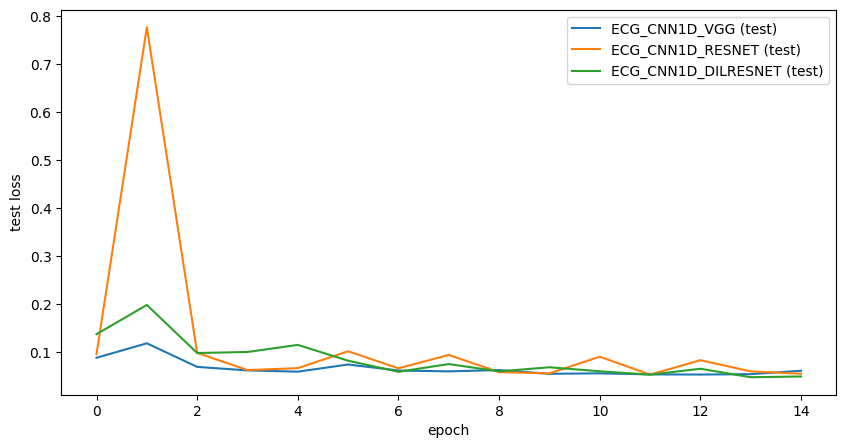

In [37]:
plt.figure(figsize=(10,5))
for name, (m, tr, te, t) in results.items():
    plt.plot(te, label=f'{name} (test)')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('test loss')

In [38]:
rows = []
for name, (m, tr, te, t) in results.items():
    rows.append({
        'model': name,
        'params': sum(p.numel() for p in m.parameters()),
        'train_loss': round(tr[-1], 4),
        'test_loss': round(te[-1], 4),
        'sec/epoch': round(t, 1),
    })
pd.DataFrame(rows)

,model,params,train_loss,test_loss,sec/epoch
0,ECG_CNN1D_VGG,155429,0.0176,0.0605,6.3
1,ECG_CNN1D_RESNET,155413,0.0203,0.0542,10.3
2,ECG_CNN1D_DILRESNET,125061,0.0274,0.0485,16.8


In [ ]:
weights = 1.0 / torch.bincount(y_train).float()
weights = (weights / weights.sum() * len(weights)).to(device)
print(weights)      # roughly [0.03, 0.95, 0.37, 3.30, 0.33]

wmodel, wtr, wte, wt = train_model(
    ECG_CNN1D_DILRESNET(n_classes),
    criterion=nn.CrossEntropyLoss(weight=weights))
evaluate(wmodel, 'DILRESNET + class weights')  

tensor([0.0293, 0.9563, 0.3673, 3.3165, 0.3306], device='cuda:0')
 Epoch:  2/15 | Train loss: 0.3326 | Test loss: 0.4944
 Epoch:  4/15 | Train loss: 0.2468 | Test loss: 0.2009
 Epoch:  6/15 | Train loss: 0.1936 | Test loss: 0.2863
 Epoch:  8/15 | Train loss: 0.1549 | Test loss: 0.2727
 Epoch: 10/15 | Train loss: 0.1455 | Test loss: 0.3164
 Epoch: 12/15 | Train loss: 0.1166 | Test loss: 0.2052
 Epoch: 14/15 | Train loss: 0.1058 | Test loss: 0.1521
DILRESNET + class weights
[[16983   730   259   118    28]
 [   45   499     7     5     0]
 [    8    17  1382    41     0]
 [    3     3     6   150     0]
 [    3     2    14     1  1588]]
              precision    recall  f1-score   support

           0      0.997     0.937     0.966     18118
           1      0.399     0.897     0.552       556
           2      0.829     0.954     0.887      1448
           3      0.476     0.926     0.629       162
           4      0.983     0.988     0.985      1608

    accuracy                   

tensor([0, 0, 0,  ..., 4, 4, 4])